In [11]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np

In [23]:
from model.autoencoder import AutoEncoder
from config.configAE import ConfigAE
from data.ae_dataset import get_dataloader

/home/ubuntu/mechanism-identification/venv_py38/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-07-17 09:59:43,261 - INFO: Created a temporary directory at /tmp/tmpqt71mt7l
2023-07-17 09:59:43,262 - INFO: Writing /tmp/tmpqt71mt7l/_remote_module_non_scriptable.py


In [31]:
from matplotlib.pyplot import plot

In [13]:
dataset = AEDataset("train")

In [14]:
item = dataset[0]

In [27]:
out_vectors = torch.load("model_outputs/out_train.pt")

In [28]:
UNIT = 512
TOTAL = 5120
N_NUM = 9

all_norm_list = []
for item in out_vectors:
    cnt = 0
    norm_list = []
    while cnt <= N_NUM:
        start_idx = cnt * UNIT
        chunk = item[start_idx:start_idx+UNIT]
        norm_list.append(LA.norm(chunk).item())
        cnt += 1
    all_norm_list.append(norm_list)

In [30]:
all_norm_list[0]

[0.9722456336021423,
 0.9731937050819397,
 0.9710209369659424,
 0.02870607003569603,
 0.01795719377696514,
 0.01610497571527958,
 0.010603050701320171,
 0.01005723886191845,
 0.008217369206249714,
 0.009308556094765663]

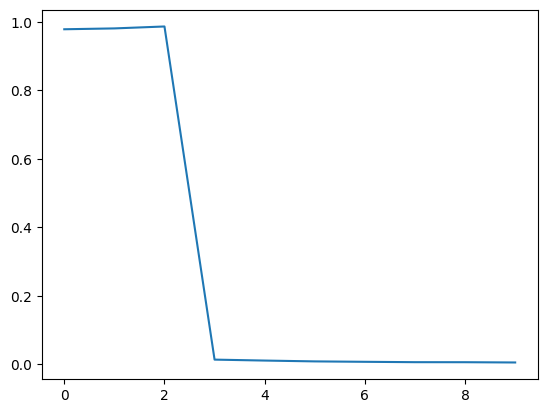

In [43]:
plot(range(10), all_norm_list[23849])